In [1]:
from mpasdiag import MPAS2DProcessor, MPASConfig, GeographicBounds, MPASSurfacePlotter, SurfaceMapStyle, MPASWindPlotter


In [2]:
proc = MPAS2DProcessor(grid_file="../data/grids/x1.10242.static.nc")
proc.load_2d_data("../data/u240k/diag")

In [3]:
tindex = 1
field = proc.dataset["t2m"].isel(Time=tindex)
lon, lat = proc.extract_2d_coordinates_for_variable("t2m", field)
temp = field.values.flatten()
pres = proc.dataset["mslp"].isel(Time=tindex).values.flatten()
uwnd = proc.dataset["u10"].isel(Time=tindex).values.flatten()
vwnd = proc.dataset["v10"].isel(Time=tindex).values.flatten()

In [4]:
cfg = MPASConfig()
cfg.lon_min, cfg.lon_max = -130, -50
cfg.lat_min, cfg.lat_max =   20,  60
cfg.remap_engine, cfg.remap_method = "kdtree", "nearest"
bounds = GeographicBounds(cfg.lon_min, cfg.lon_max, cfg.lat_min, cfg.lat_max)

In [5]:
plotter = MPASSurfacePlotter(figsize=(14, 11), dpi=300)
wind = MPASWindPlotter(figsize=(14, 11), dpi=300)

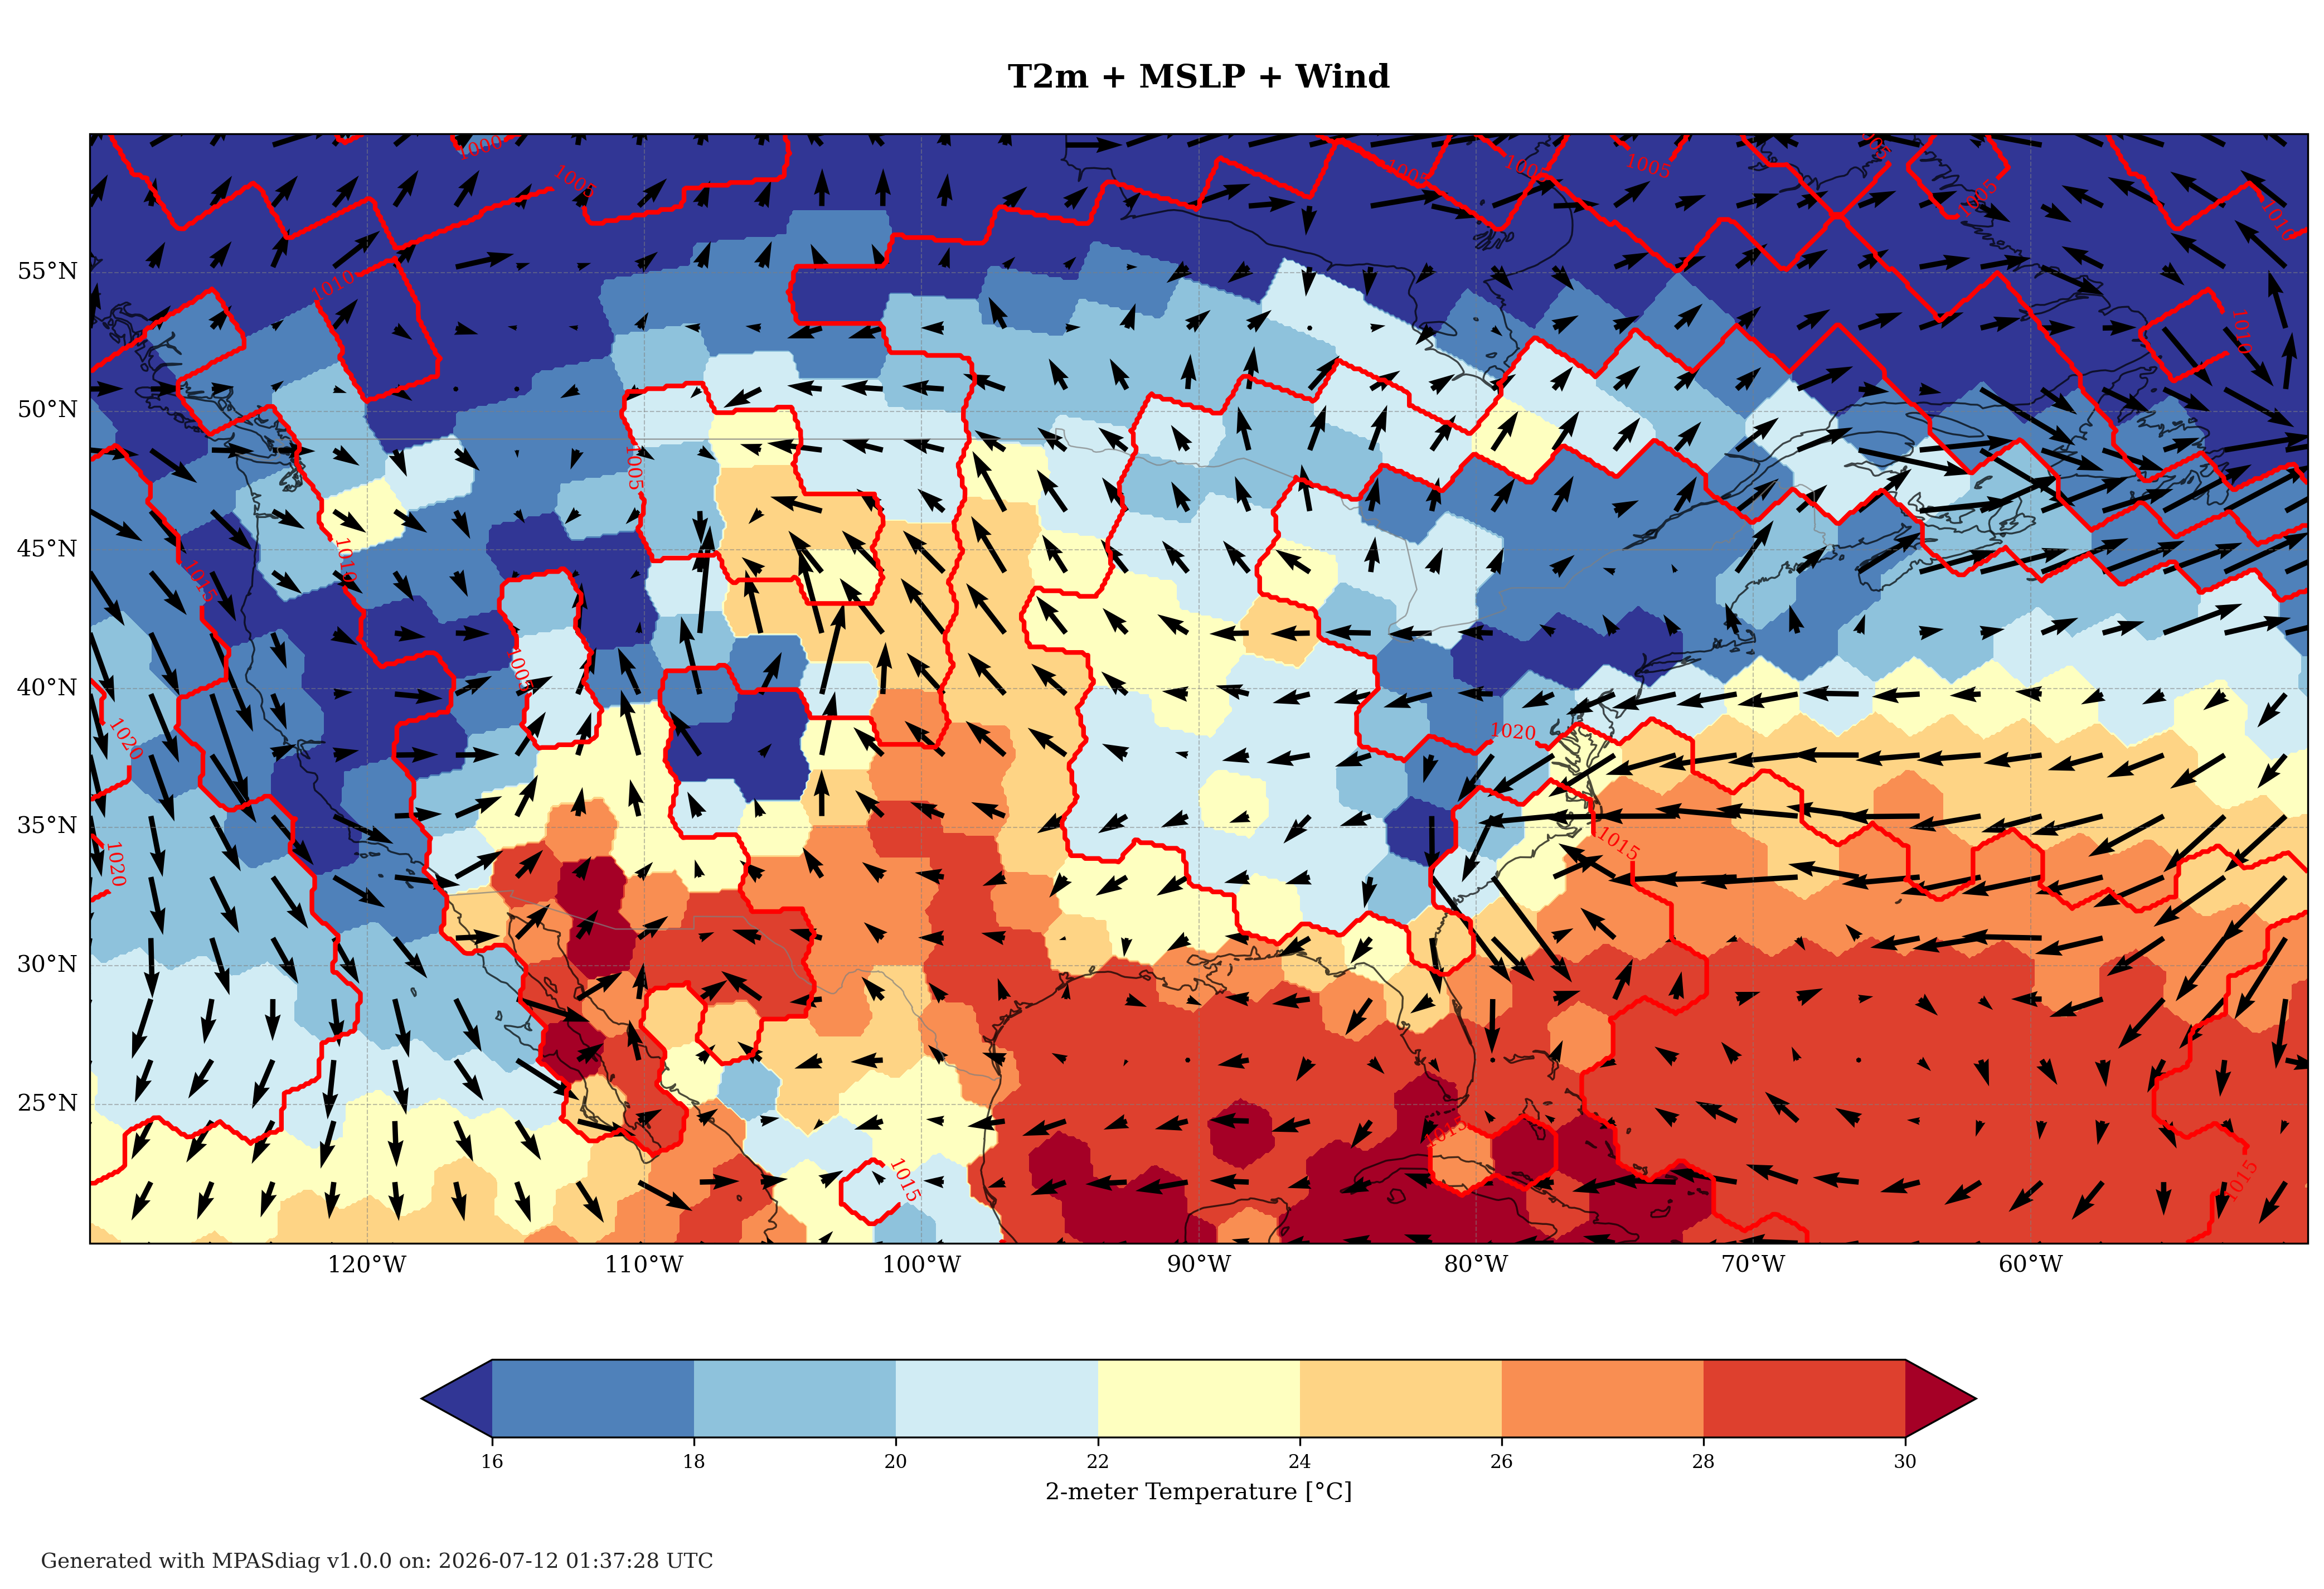

In [6]:
# Base: filled temperature
fig, ax = plotter.create_surface_map(
    lon=lon, lat=lat, data=temp, var_name="t2m", bounds=bounds, config=cfg,
    style=SurfaceMapStyle(plot_type="contourf", grid_resolution=0.1, title="T2m + MSLP + Wind"),
)

# Overlay 1: MSLP contour lines
plotter.add_surface_overlay(
    ax, lon, lat,
    {"data": pres, "var_name": "mslp", "plot_type": "contour",
     "levels": [995, 1000, 1005, 1010, 1015, 1020], "colors": "red",
     "linewidth": 2.0, "grid_resolution": 0.1, "add_labels": True},
    lon_min=cfg.lon_min, lon_max=cfg.lon_max,
    lat_min=cfg.lat_min, lat_max=cfg.lat_max,
)

# Overlay 2: 10-m wind arrows
wind.add_wind_overlay(
    ax, lon, lat,
    {"u_data": uwnd, "v_data": vwnd, "plot_type": "arrows",
     "subsample": "-1", "colors": "black", "grid_resolution": 0.1},
    lon_min=cfg.lon_min, lon_max=cfg.lon_max,
    lat_min=cfg.lat_min, lat_max=cfg.lat_max, config=cfg,
)

In [7]:
plotter.save_plot("./output/overlay_t2m_mslp_wind", formats=["png"])
plotter.close_plot()